<a href="https://colab.research.google.com/github/deekshdechamma/NLP/blob/main/nlp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NLP Project 8: Product Feedback Analysis
Problem Statement
A retail company has recently launched new products and receives customer feedback through
surveys, online forms, and e-commerce platforms. Customers share opinions regarding product quality,
pricing, packaging, and usability. The management wants to analyze this feedback efficiently to
understand customer expectations and improve product performance. NLP techniques can help
automate feedback analysis and provide meaningful insights for business decisions.
Tasks
1. Collect product feedback data.
2. Preprocess feedback text.
3. Analyze customer sentiments.
4. Identify product improvement areas.
5. Generate business insights.

In [1]:
#Step 1 — Install libraries
!pip install nltk wordcloud vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.7 MB/s eta 0:00:00


In [2]:
#Step 2 — Import libraries
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "niraliivaghani/flipkart-product-customer-reviews-dataset"
)

print("Dataset path:", path)

100%|██████████| 3.79M/3.79M [00:00<00:00, 146MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/versions/1


In [4]:
import os

print(os.listdir(path))

['Dataset-SA.csv']


In [5]:
import pandas as pd
import os

files = os.listdir(path)

csv_files = [f for f in files if f.endswith(".csv")]

print("CSV files:", csv_files)

df = pd.read_csv(
    os.path.join(path, csv_files[0])
)

df.head()

CSV files: ['Dataset-SA.csv']


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [6]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (205052, 6)

Columns:
['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']

Missing Values:
product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

Duplicate Rows:
34375


In [7]:
df.head(10)

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral
5,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,the cooler is really fantastic and provides go...,positive
6,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,highly recommended,very good product,positive
7,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,nice,very nice,positive
8,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,unsatisfactory,very bad cooler,negative
9,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,4,worth the money,very good,positive


In [8]:
print(df.columns.tolist())

['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']


In [9]:
#Step 5 — Find the review column automatically
print(df.columns)

review_col = None

for col in df.columns:
    if col.lower() in ['review', 'reviews', 'reviewtext', 'review_text']:
        review_col = col
        break

print("Review column:", review_col)

Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')
Review column: Review


In [10]:
#Step 6 — Remove missing and duplicate reviews
df = df.dropna(subset=[review_col])

df = df.drop_duplicates(subset=[review_col])

df = df.reset_index(drop=True)

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (1324, 6)


In [11]:
#Step 7 — Text preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # lowercase
    text = str(text).lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # tokenize
    words = word_tokenize(text)

    # remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
        and len(word) > 1
    ]

    return ' '.join(words)

In [12]:
df['Cleaned_Review'] = df[review_col].apply(preprocess_text)

df[[review_col, 'Cleaned_Review']].head(10)

,Review,Cleaned_Review
0,super!,super
1,awesome,awesome
2,fair,fair
3,useless product,useless product
4,highly recommended,highly recommended
5,nice,nice
6,unsatisfactory,unsatisfactory
7,worth the money,worth money
8,great product,great product
9,mind-blowing purchase,mindblowing purchase


In [13]:
#Step 8 — Check the existing sentiment column
sentiment_col = None

for col in df.columns:
    if col.lower() == 'sentiment':
        sentiment_col = col
        break

print("Sentiment column:", sentiment_col)

Sentiment column: Sentiment


In [14]:
print(df[sentiment_col].value_counts())

Sentiment
positive    1015
negative     260
neutral       49
Name: count, dtype: int64


In [15]:
#Step 9 — Sentiment distribution
sentiment_counts = df[sentiment_col].value_counts()

print(sentiment_counts)

Sentiment
positive    1015
negative     260
neutral       49
Name: count, dtype: int64


In [16]:
sentiment_percentage = (
    df[sentiment_col].value_counts(normalize=True) * 100
)

print(sentiment_percentage.round(2))

Sentiment
positive    76.66
negative    19.64
neutral      3.70
Name: proportion, dtype: float64


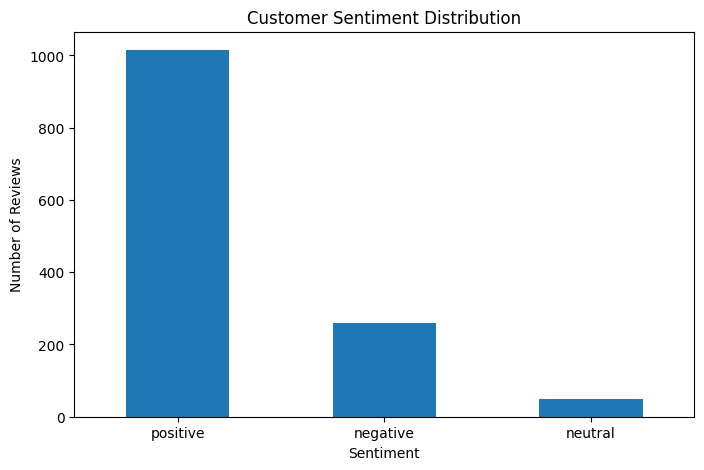

In [17]:
#Step 10 — Sentiment bar chart
sentiment_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

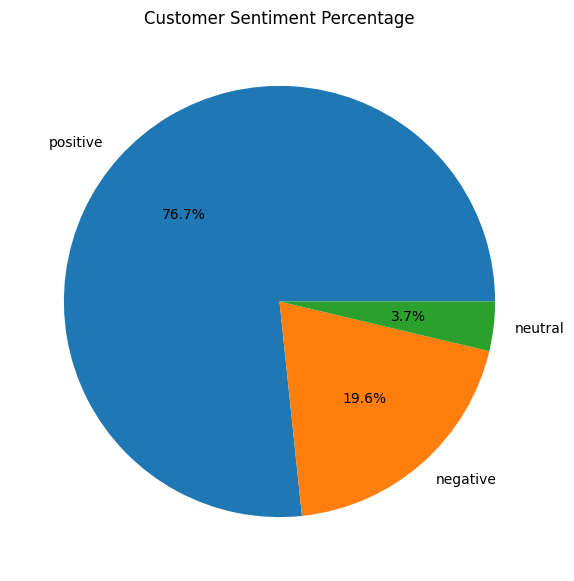

In [18]:
#Step 11 — Sentiment pie chart
sentiment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7)
)

plt.title("Customer Sentiment Percentage")
plt.ylabel("")
plt.show()

In [19]:
#Step 12 — Identify improvement areas
improvement_keywords = {

    'Quality': [
        'quality', 'poor', 'broken', 'damage',
        'damaged', 'defective', 'material',
        'durable', 'durability'
    ],

    'Pricing': [
        'price', 'expensive', 'cost',
        'cheap', 'overpriced', 'money',
        'value'
    ],

    'Packaging': [
        'package', 'packaging', 'packed',
        'packing', 'box', 'wrapper'
    ],

    'Usability': [
        'use', 'easy', 'difficult',
        'hard', 'confusing', 'comfortable',
        'uncomfortable', 'user'
    ]
}

In [20]:
#Step 13 — Categorize feedback
def identify_area(text):

    text = str(text).lower()

    areas = []

    for area, keywords in improvement_keywords.items():

        if any(keyword in text for keyword in keywords):
            areas.append(area)

    if not areas:
        return 'Other'

    return ', '.join(areas)

In [21]:
df['Improvement_Area'] = df['Cleaned_Review'].apply(identify_area)

df[
    [review_col, 'Cleaned_Review', sentiment_col, 'Improvement_Area']
].head(20)

,Review,Cleaned_Review,Sentiment,Improvement_Area
0,super!,super,positive,Other
1,awesome,awesome,positive,Other
2,fair,fair,positive,Other
3,useless product,useless product,negative,Usability
4,highly recommended,highly recommended,positive,Other
5,nice,nice,positive,Other
6,unsatisfactory,unsatisfactory,negative,Other
7,worth the money,worth money,positive,Pricing
8,great product,great product,positive,Other
9,mind-blowing purchase,mindblowing purchase,positive,Other


In [22]:
#Step 14 — Select negative reviews
df[sentiment_col] = (
    df[sentiment_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

In [23]:
negative_df = df[
    df[sentiment_col] == 'negative'
]

print("Total Negative Reviews:", len(negative_df))

negative_df[
    [review_col, 'Improvement_Area']
].head(10)

Total Negative Reviews: 260


,Review,Improvement_Area
3,useless product,Usability
6,unsatisfactory,Other
21,expected a better product,Other
25,waste of money!,Pricing
31,worst experience ever!,Other
34,"like an assembled, one can get for 4.5k cheap ...","Quality, Pricing"
35,not good,Other
37,slightly disappointed,Other
38,horrible,Other
39,very poor,Quality


In [24]:
#Step 15 — Count improvement areas
area_counts = {
    'Quality': 0,
    'Pricing': 0,
    'Packaging': 0,
    'Usability': 0
}

for text in negative_df['Cleaned_Review']:

    text = str(text).lower()

    for area, keywords in improvement_keywords.items():

        if any(keyword in text for keyword in keywords):
            area_counts[area] += 1

print(area_counts)

{'Quality': 38, 'Pricing': 27, 'Packaging': 2, 'Usability': 10}


In [26]:
#Step 16 — Convert results to DataFrame
area_df = pd.DataFrame(
    list(area_counts.items()),
    columns=[
        'Improvement Area',
        'Negative Review Count'
    ]
)

area_df

,Improvement Area,Negative Review Count
0,Quality,38
1,Pricing,27
2,Packaging,2
3,Usability,10


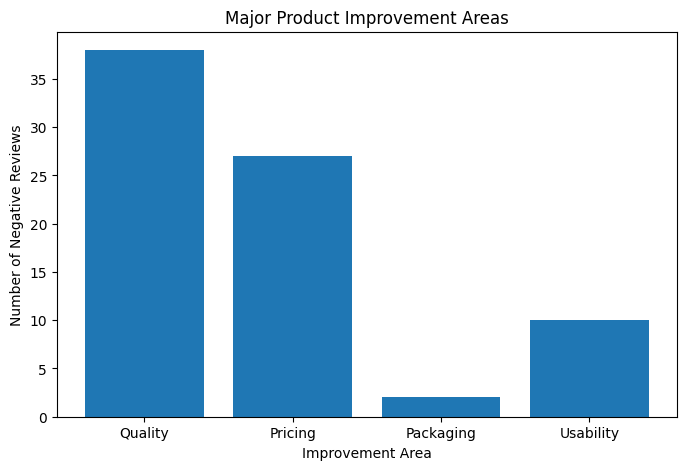

In [27]:
#Step 17 — Improvement-area graph
plt.figure(figsize=(8, 5))

plt.bar(
    area_df['Improvement Area'],
    area_df['Negative Review Count']
)

plt.title("Major Product Improvement Areas")
plt.xlabel("Improvement Area")
plt.ylabel("Number of Negative Reviews")

plt.show()

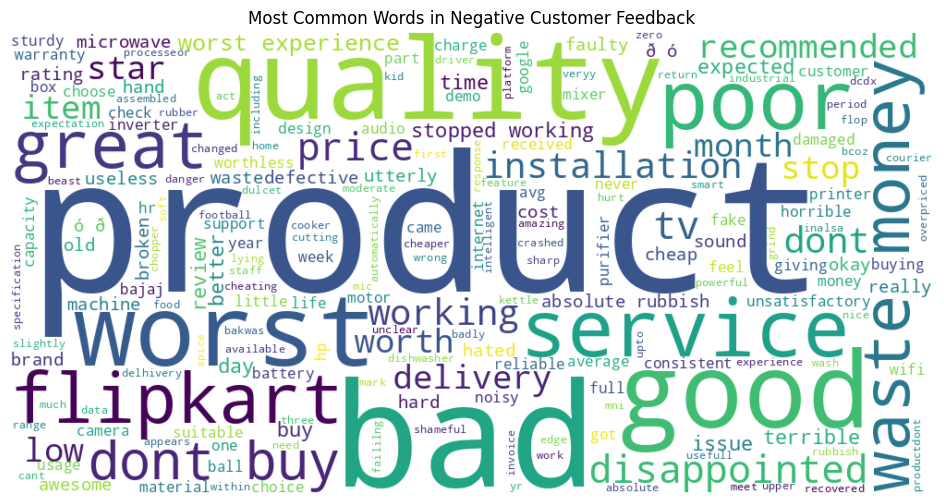

In [28]:
#Step 18 — Negative review WordCloud
negative_text = ' '.join(
    negative_df['Cleaned_Review'].astype(str)
)

if negative_text.strip():

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white'
    ).generate(negative_text)

    plt.figure(figsize=(12, 6))

    plt.imshow(
        wordcloud,
        interpolation='bilinear'
    )

    plt.axis('off')

    plt.title(
        "Most Common Words in Negative Customer Feedback"
    )

    plt.show()

else:
    print("No negative reviews found.")

In [30]:
from collections import Counter

#Step 19 — Most common complaint words
all_words = ' '.join(
    negative_df['Cleaned_Review']
).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(15)

common_words

[('product', 55),
 ('bad', 29),
 ('worst', 24),
 ('quality', 24),
 ('good', 21),
 ('dont', 14),
 ('poor', 12),
 ('buy', 12),
 ('waste', 11),
 ('service', 11),
 ('money', 10),
 ('working', 10),
 ('flipkart', 9),
 ('great', 8),
 ('disappointed', 7)]

In [31]:
common_words_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

common_words_df

,Word,Frequency
0,product,55
1,bad,29
2,worst,24
3,quality,24
4,good,21
5,dont,14
6,poor,12
7,buy,12
8,waste,11
9,service,11


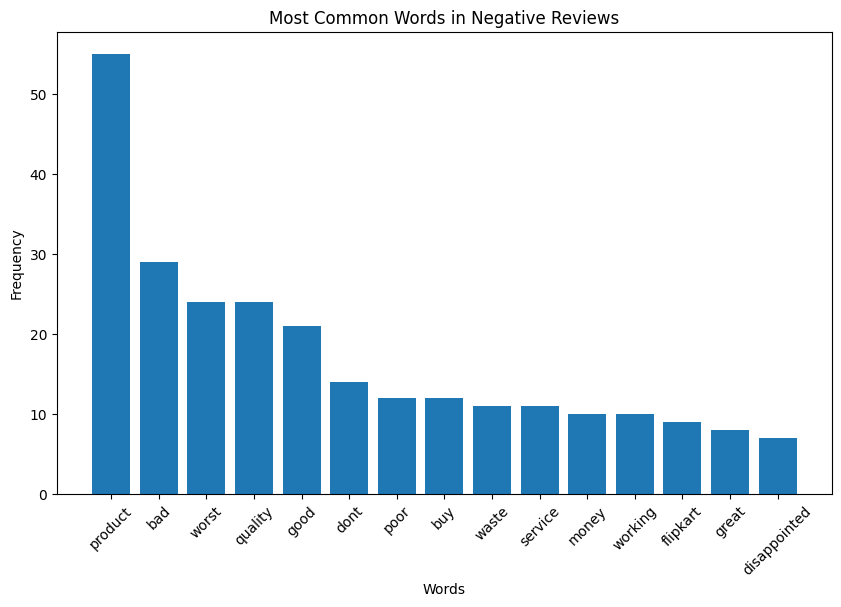

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    common_words_df['Word'],
    common_words_df['Frequency']
)

plt.title("Most Common Words in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [33]:
#Step 20 — Generate final business insights
total = len(df)

positive = (
    df[sentiment_col] == 'positive'
).sum()

negative = (
    df[sentiment_col] == 'negative'
).sum()

neutral = (
    df[sentiment_col] == 'neutral'
).sum()

print("=" * 50)
print("PRODUCT FEEDBACK ANALYSIS REPORT")
print("=" * 50)

print("\nTotal Reviews:", total)

print(
    f"Positive Reviews: {positive} "
    f"({positive/total*100:.2f}%)"
)

print(
    f"Negative Reviews: {negative} "
    f"({negative/total*100:.2f}%)"
)

print(
    f"Neutral Reviews: {neutral} "
    f"({neutral/total*100:.2f}%)"
)

print("\nPRODUCT IMPROVEMENT AREAS")
print("-" * 30)

for area, count in sorted(
    area_counts.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{area}: {count}")

PRODUCT FEEDBACK ANALYSIS REPORT

Total Reviews: 1324
Positive Reviews: 1015 (76.66%)
Negative Reviews: 260 (19.64%)
Neutral Reviews: 49 (3.70%)

PRODUCT IMPROVEMENT AREAS
------------------------------
Quality: 38
Pricing: 27
Usability: 10
Packaging: 2


In [34]:
#Step 21 — Automatically generate a recommendation
major_problem = max(
    area_counts,
    key=area_counts.get
)

print("\nMAJOR IMPROVEMENT AREA")
print("----------------------")

print(major_problem)

print("\nBUSINESS INSIGHT")
print("----------------")

print(
    f"The analysis indicates that {major_problem} "
    f"is a major area of concern among negative "
    f"customer reviews. The company should prioritize "
    f"improvements in {major_problem.lower()} to enhance "
    f"customer satisfaction and product performance."
)


MAJOR IMPROVEMENT AREA
----------------------
Quality

BUSINESS INSIGHT
----------------
The analysis indicates that Quality is a major area of concern among negative customer reviews. The company should prioritize improvements in quality to enhance customer satisfaction and product performance.


In [35]:
#Step 22 — Save your NLP results
output_columns = [
    review_col,
    'Cleaned_Review',
    sentiment_col,
    'Improvement_Area'
]

df[output_columns].to_csv(
    'Product_Feedback_NLP_Results.csv',
    index=False
)

print("File saved successfully!")

File saved successfully!
